## Fuzzy AHP — Solar Site Criteria

This notebook was developed by Mohsen Larni, Morteza Nazaripour, and Eakalak Khan for the research paper **"Integrated Geospatial Multi-Criteria Framework for Utility-Scale Solar PV Plant Site Selection with Techno-Economic and Environmental Impact Assessments: A Case Study of Nevada, United States"**.

**Setup:** run the next cell to install from `requirements.txt` in this folder.


In [ ]:
#%pip install -r requirements.txt


## Notebook structure

1. **Setup** — install dependencies, import libraries, criterion labels
2. **Fuzzy pairwise matrix** — triangular fuzzy numbers `(L, M, U)`; `data_crisp` (midpoints) for sensitivity only
3. **Fuzzy AHP** — run `fuzzy_ahp_method` on the fuzzy matrix
4. **Results** — fuzzy / defuzzified / normalized weights, pie chart, consistency ratio (RC)
5. **Sensitivity** — OAT on crisp midpoints; `.txt` and matching `.png` pie charts in `sensitivity_weights_oat/`, `.xlsx` in `results_summary/`


## 1. Setup

Imports and criterion labels.


In [ ]:
import copy
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyDecision.algorithm import fuzzy_ahp_method


In [ ]:
# Criterion names (same order as rows/columns in the pairwise matrices).
labels = ['GHI', 'Average temperature', 'Slope', 'Aspect', 'Surface Albedo', 'Air pressure',
          'Proximity to urban area', 'Proximity to power transmission line', 'Proximity to main roads',
          'Precipitation', 'Cloud amount', 'Relative humidity']
labels

['GHI',
 'Average temperature',
 'Slope',
 'Aspect',
 'Surface Albedo',
 'Air pressure',
 'Proximity to urban area',
 'Proximity to power transmission line',
 'Proximity to main roads',
 'Precipitation',
 'Cloud amount',
 'Relative humidity']

## 2. Fuzzy pairwise comparison matrix

Each cell is a triangular fuzzy number `(L, M, U)` on the comparison scale. `data_crisp` holds the midpoint `M` for each cell and is used only inside the OAT sensitivity section (perturb → reciprocal → fuzzify → fuzzy AHP); it is not shown as a separate crisp matrix here.


In [ ]:
# Fuzzy pairwise comparison matrix: each entry is (lower, modal, upper) for fuzzy_ahp_method.
# Values match the prior expert-aggregation pipeline (consensus PCM → reciprocals → fuzzification).

data = [
    [(1, 1, 1), (1, 2, 3), (1, 2, 3), (2, 3, 4), (2, 3, 4), (1, 2, 3), (3, 4, 5), (2, 3, 4), (4, 5, 6), (6, 7, 8), (6, 7, 8), (6, 7, 8)],
    [(0.3333333333333333, 0.5, 1), (1, 1, 1), (1, 2, 3), (1, 2, 3), (2, 3, 4), (1, 2, 3), (2, 3, 4), (1, 2, 3), (3, 4, 5), (4, 5, 6), (4, 5, 6), (4, 5, 6)],
    [(0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (1, 2, 3), (1, 2, 3), (1, 2, 3), (2, 3, 4), (1, 2, 3), (2, 3, 4), (3, 4, 5), (3, 4, 5), (3, 4, 5)],
    [(0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (1, 2, 3), (1, 1, 1), (1, 2, 3), (1, 2, 3), (1, 2, 3), (2, 3, 4), (2, 3, 4), (2, 3, 4)],
    [(0.25, 0.3333333333333333, 0.5), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (0.3333333333333333, 0.5, 1), (1, 2, 3), (1, 1, 1), (1, 2, 3), (1, 2, 3), (1, 2, 3), (1, 2, 3)],
    [(0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (1, 2, 3), (1, 1, 1), (1, 2, 3), (1, 2, 3), (1, 2, 3), (2, 3, 4), (2, 3, 4), (2, 3, 4)],
    [(0.2, 0.25, 0.3333333333333333), (0.25, 0.3333333333333333, 0.5), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (0.3333333333333333, 0.5, 1), (1, 2, 3), (1, 2, 3), (1, 2, 3), (1, 2, 3)],
    [(0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (0.3333333333333333, 0.5, 1), (1, 2, 3), (1, 1, 1), (1, 2, 3), (1, 2, 3), (1, 2, 3), (1, 2, 3)],
    [(0.16666666666666666, 0.2, 0.25), (0.2, 0.25, 0.3333333333333333), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (1, 2, 3), (1, 2, 3), (1, 2, 3)],
    [(0.125, 0.14285714285714285, 0.16666666666666666), (0.16666666666666666, 0.2, 0.25), (0.2, 0.25, 0.3333333333333333), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (1, 1, 1), (1, 1, 1)],
    [(0.125, 0.14285714285714285, 0.16666666666666666), (0.16666666666666666, 0.2, 0.25), (0.2, 0.25, 0.3333333333333333), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (1, 1, 1), (1, 1, 1)],
    [(0.125, 0.14285714285714285, 0.16666666666666666), (0.16666666666666666, 0.2, 0.25), (0.2, 0.25, 0.3333333333333333), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.25, 0.3333333333333333, 0.5), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (0.3333333333333333, 0.5, 1), (1, 1, 1), (1, 1, 1), (1, 1, 1)],
]

n = len(data)
# Middle of each triplet = crisp comparison used internally for OAT sensitivity only.
data_crisp = [[float(data[i][j][1]) for j in range(n)] for i in range(n)]

pd.DataFrame(data, columns=labels, index=labels)


,GHI,Average temperature,Slope,Aspect,Surface Albedo,Air pressure,Proximity to urban area,Proximity to power transmission line,Proximity to main roads,Precipitation,Cloud amount,Relative humidity
GHI,"(1, 1, 1)","(1, 2, 3)","(1, 2, 3)","(2, 3, 4)","(2, 3, 4)","(1, 2, 3)","(3, 4, 5)","(2, 3, 4)","(4, 5, 6)","(6, 7, 8)","(6, 7, 8)","(6, 7, 8)"
Average temperature,"(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(1, 2, 3)","(1, 2, 3)","(2, 3, 4)","(1, 2, 3)","(2, 3, 4)","(1, 2, 3)","(3, 4, 5)","(4, 5, 6)","(4, 5, 6)","(4, 5, 6)"
Slope,"(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)","(2, 3, 4)","(1, 2, 3)","(2, 3, 4)","(3, 4, 5)","(3, 4, 5)","(3, 4, 5)"
Aspect,"(0.25, 0.3333333333333333, 0.5)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(1, 2, 3)","(1, 1, 1)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)","(2, 3, 4)","(2, 3, 4)","(2, 3, 4)"
Surface Albedo,"(0.25, 0.3333333333333333, 0.5)","(0.25, 0.3333333333333333, 0.5)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(0.3333333333333333, 0.5, 1)","(1, 2, 3)","(1, 1, 1)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)"
Air pressure,"(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(1, 2, 3)","(1, 1, 1)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)","(2, 3, 4)","(2, 3, 4)","(2, 3, 4)"
Proximity to urban area,"(0.2, 0.25, 0.3333333333333333)","(0.25, 0.3333333333333333, 0.5)","(0.25, 0.3333333333333333, 0.5)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(0.3333333333333333, 0.5, 1)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)"
Proximity to power transmission line,"(0.25, 0.3333333333333333, 0.5)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(0.3333333333333333, 0.5, 1)","(1, 2, 3)","(1, 1, 1)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)"
Proximity to main roads,"(0.16666666666666666, 0.2, 0.25)","(0.2, 0.25, 0.3333333333333333)","(0.25, 0.3333333333333333, 0.5)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(1, 2, 3)","(1, 2, 3)","(1, 2, 3)"
Precipitation,"(0.125, 0.14285714285714285, 0.16666666666666666)","(0.16666666666666666, 0.2, 0.25)","(0.2, 0.25, 0.3333333333333333)","(0.25, 0.3333333333333333, 0.5)","(0.3333333333333333, 0.5, 1)","(0.25, 0.3333333333333333, 0.5)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(0.3333333333333333, 0.5, 1)","(1, 1, 1)","(1, 1, 1)","(1, 1, 1)"


## 3. Fuzzy AHP solution

`fuzzy_ahp_method` → weights and RC.


In [ ]:
# (n, n) array of (L, M, U) tuples
np_matrix = pd.DataFrame(data).to_numpy()# np_matrix


In [ ]:
# fuzzy_weights, defuzzified_weights, normalized_weights, rc
fuzzy_weights, defuzzified_weights, normalized_weights, rc = fuzzy_ahp_method(np_matrix)

## 4. Results

Weights, pie chart, RC.


In [ ]:
# Fuzzy weights
for i in range(0, len(fuzzy_weights)):
    print(np.around(fuzzy_weights[i], 3), f" : {labels[i]}")

[0.109 0.219 0.413]  : GHI
[0.075 0.161 0.323]  : Average temperature
[0.058 0.128 0.27 ]  : Slope
[0.042 0.09  0.191]  : Aspect
[0.029 0.063 0.14 ]  : Surface Albedo
[0.043 0.094 0.203]  : Air pressure
[0.023 0.05  0.116]  : Proximity to urban area
[0.029 0.065 0.148]  : Proximity to power transmission line
[0.02  0.042 0.1  ]  : Proximity to main roads
[0.017 0.029 0.062]  : Precipitation
[0.017 0.029 0.062]  : Cloud amount
[0.017 0.029 0.062]  : Relative humidity


In [ ]:
# Defuzzified weights
# defuzzified_weights = [np.floor(defuzzified_weights[i] * 100) / 100 for i in range(0, len(defuzzified_weights))]

for i in range(0, len(defuzzified_weights)):
    print(round(defuzzified_weights[i], 3), f" : {labels[i]}")

0.247  : GHI
0.186  : Average temperature
0.152  : Slope
0.108  : Aspect
0.077  : Surface Albedo
0.113  : Air pressure
0.063  : Proximity to urban area
0.081  : Proximity to power transmission line
0.054  : Proximity to main roads
0.036  : Precipitation
0.036  : Cloud amount
0.036  : Relative humidity


In [ ]:
# Sum of rounded defuzzified weights
sum = 0
for i in range(len(defuzzified_weights)):
    sum += round(defuzzified_weights[i], 2)
sum

1.2000000000000002

In [ ]:
# Normalized weights
for i in range(0, len(normalized_weights)):
    print(round(normalized_weights[i], 2), f" : {labels[i]}")

0.21  : GHI
0.16  : Average temperature
0.13  : Slope
0.09  : Aspect
0.06  : Surface Albedo
0.1  : Air pressure
0.05  : Proximity to urban area
0.07  : Proximity to power transmission line
0.05  : Proximity to main roads
0.03  : Precipitation
0.03  : Cloud amount
0.03  : Relative humidity


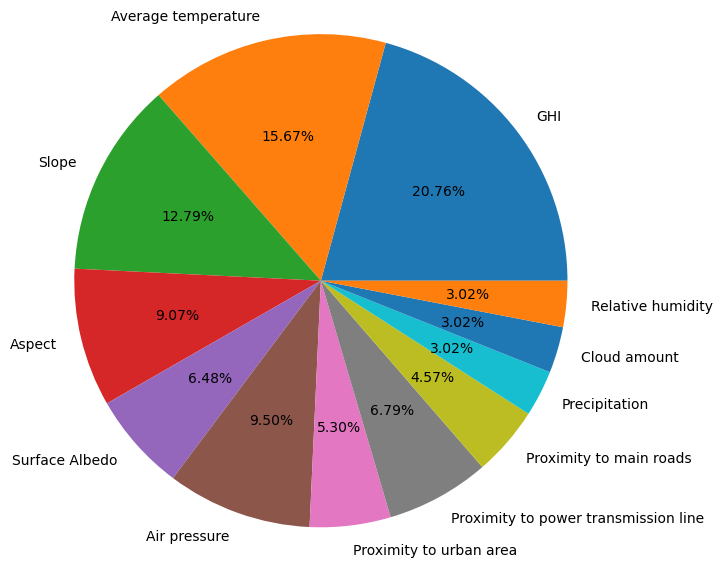

In [ ]:
# Pie chart
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(normalized_weights, labels=labels, autopct='%1.2f%%')

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
# plt.title('')
plt.show()


In [ ]:
# RC (consistency ratio)
print('RC: ', rc)
if (rc > 0.10):
  print('The solution is inconsistent, the pairwise comparisons must be reviewed')
else:
  print('The solution is consistent')


RC:  0.03608953028517545
The solution is consistent


## 5. One-at-a-time (OAT) sensitivity

OAT on the crisp midpoints derived from the fuzzy matrix (±1 / ±2 on the Saaty scale). For each run, normalized weights go to `sensitivity_weights_oat/*.txt` with a matching pie chart `*.png`. Excel tables in `results_summary/`.


In [ ]:
# OAT sensitivity: perturb `data_crisp` (modal midpoints of `data`), then reciprocal → fuzzify → fuzzy AHP.
# Each scenario writes a .txt file and a .png pie chart with the same basename under sensitivity_weights_oat/.

import math
import re

AHP_SCALE = [1/9, 1/8, 1/7, 1/6, 1/5, 1/4, 1/3, 1/2,
             1, 2, 3, 4, 5, 6, 7, 8, 9]


def inverse_number(number):
    """Reciprocal 1/x for filling the lower triangle from the upper triangle."""
    if number == 0:
        raise ZeroDivisionError("Cannot inverse 0.")
    return 1.0 / number


def fazzy_from_decimal(x):
    """Turn a crisp Saaty-style ratio into a triangular fuzzy number (L, M, U) for fuzzy_ahp_method."""
    if x == 0:
        return (0.0, 0.0, 0.0)
    if x == 1 or x == 9:
        return (x, x, x)
    if x in [2, 3, 4, 5, 6, 7, 8]:
        return (x - 1, x, x + 1)
    if inverse_number(x) in [2, 3, 4, 5, 6, 7, 8]:
        inv = inverse_number(x)
        return (inverse_number(inv + 1), inverse_number(inv), inverse_number(inv - 1))
    if inverse_number(x) == 9:
        return (x, x, x)


def _slug_for_filename(s):
    """Turn a label into a short token safe for filenames."""
    t = re.sub(r"[^\w\-.]+", "_", str(s).strip())
    t = re.sub(r"_+", "_", t).strip("_")
    return t or "criterion"


def _pair_slug(labels, i, j):
    """`label_i_vs_label_j` for matrix position (i, j)."""
    return f"{_slug_for_filename(labels[i])}_vs_{_slug_for_filename(labels[j])}"


def _run_fuzzy_from_crisp(dc):
    """Crisp PCM -> reciprocals -> fuzzy triples -> fuzzy_ahp_method; return weights and RC."""
    d = copy.deepcopy(dc)
    n = len(d)
    for row in range(n):
        for col in range(row):
            d[row][col] = inverse_number(d[col][row])
    for x in range(n):
        for y in range(n):
            d[x][y] = fazzy_from_decimal(d[x][y])
    np_m = pd.DataFrame(d).to_numpy()
    _fw, _dw, nw, r = fuzzy_ahp_method(np_m)
    return list(nw), r


def _ahp_scale_index(v):
    """Index on `AHP_SCALE` closest to `v` (distance in log space)."""
    lg = math.log(v)
    return min(range(len(AHP_SCALE)), key=lambda k: abs(math.log(AHP_SCALE[k]) - lg))


# Baseline: unperturbed `data_crisp` → fuzzy AHP (reference for OAT comparisons)
baseline_w, baseline_rc = _run_fuzzy_from_crisp(data_crisp)
baseline_w = np.asarray(baseline_w, dtype=float)
baseline_order = np.argsort(-baseline_w)
winner_idx = int(baseline_order[0])
winner_name = labels[winner_idx]

n = len(data_crisp)


OAT_WEIGHTS_DIR = Path("sensitivity_weights_oat")
OAT_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_SUMMARY_DIR = Path("results_summary")
RESULTS_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)


def _save_weights_txt(path: Path, nw, header_lines):
    """Write comment header lines, then TSV: criterion, normalized_weight."""
    with open(path, "w", encoding="utf-8") as f:
        for line in header_lines:
            f.write(line + "\n")
        f.write("\n")
        f.write("criterion\tnormalized_weight\n")
        for lab, w in zip(labels, nw):
            f.write(f"{lab}\t{w:.12g}\n")


def _save_weights_pie(path_png: Path, nw, title=None):
    """Same styling as section 4 (labels + percent labels); saved next to the matching .txt file."""
    nw = np.asarray(nw, dtype=float)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie(nw, labels=labels, autopct="%1.2f%%")
    plt.axis("equal")
    if title:
        ax.set_title(title, fontsize=9)
    fig.savefig(path_png, dpi=150, bbox_inches="tight")
    plt.close(fig)


_save_weights_txt(
    OAT_WEIGHTS_DIR / "baseline.txt",
    baseline_w,
    [
        "Baseline (data_crisp midpoints from fuzzy matrix -> fuzzy AHP)",
        f"winner: {winner_name}",
        f"RC: {float(baseline_rc):.6g}",
    ],
)
_save_weights_pie(OAT_WEIGHTS_DIR / "baseline.png", baseline_w, title="baseline")


def _oat_rows(step_shift):
    """For each upper-tri cell, try ±step_shift on AHP_SCALE; collect rows + save .txt + .png."""
    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            v0 = data_crisp[i][j]
            if v0 <= 0:
                continue
            k0 = _ahp_scale_index(v0)
            for sign, base in [(-1, "down"), (+1, "up")]:
                k1 = k0 + sign * step_shift
                if k1 < 0 or k1 >= len(AHP_SCALE):
                    continue
                v1 = AHP_SCALE[k1]
                if abs(v1 - v0) < 1e-12:
                    continue
                pert = copy.deepcopy(data_crisp)
                pert[i][j] = v1
                nw, r = _run_fuzzy_from_crisp(pert)
                nw = np.asarray(nw, dtype=float)
                w_idx = int(np.argmax(nw))
                top3_new = tuple(np.argsort(-nw)[:3])
                top3_base = tuple(baseline_order[:3])
                ch = base if step_shift == 1 else f"{base}×{step_shift}"
                safe_ch = ch.replace("×", "x")
                pair_slug = _pair_slug(labels, i, j)
                if len(pair_slug) > 120:
                    pair_slug = pair_slug[:117] + "..."
                fname = f"step{step_shift}_{pair_slug}_{safe_ch}_from{v0:g}_to{v1:g}.txt"
                fname = fname.replace("/", "d")
                out_path = OAT_WEIGHTS_DIR / fname
                pair = f"{labels[i]} vs {labels[j]}"
                header = [
                    f"OAT perturbation (step size {step_shift} on AHP scale)",
                    f"pair: {pair}",
                    f"matrix indices (upper tri): i={i}, j={j}",
                    f"change: {ch}  (comparison value {v0} -> {v1})",
                    f"RC: {float(r):.6g}",
                    f"saved_as: {out_path.name}",
                ]
                _save_weights_txt(out_path, nw, header)
                _save_weights_pie(out_path.with_suffix(".png"), nw, title=out_path.stem)
                rows.append({
                    "pair": pair,
                    "change": ch,
                    "from": v0,
                    "to": v1,
                    "RC": round(float(r), 4),
                    "winner_same": w_idx == winner_idx,
                    "top3_same": top3_new == top3_base,
                    "max_delta_weight": round(float(np.max(np.abs(nw - baseline_w))), 4),
                    "weights_file": out_path.name,
                })
    return rows


def _print_oat_block(sens_df, header_line):
    """Print flip counts, full scenario table, largest weight deltas, and winner-change list."""
    show = ["pair", "change", "from", "to", "winner_same", "top3_same", "max_delta_weight", "RC", "weights_file"]
    n_scen = len(sens_df)
    n_flip = int((~sens_df["winner_same"]).sum()) if n_scen else 0
    print(header_line)
    print(f"Baseline winner: {winner_name}")
    print(f"Baseline RC: {baseline_rc:.4f}")
    print(f"Scenarios: {n_scen} | Winner changed: {n_flip} ({100 * n_flip / max(n_scen, 1):.1f}%)")
    print()
    print("(1) Ranking / winner stable? → winner_same, top3_same")
    print("(2) Weight stability? → max_delta_weight")
    print()
    if n_scen:
        pd.set_option("display.max_rows", 200)
        pd.set_option("display.width", 200)
        print(sens_df[show].to_string(index=False))
        worst = sens_df.nlargest(8, "max_delta_weight")
        print("\n--- Largest weight swings ---")
        print(worst[show].to_string(index=False))
        flips = sens_df[~sens_df["winner_same"]]
        if len(flips):
            print("\n--- Winner changed in these scenarios ---")
            print(flips[show].to_string(index=False))
        else:
            print("\nWinner unchanged for all perturbations in this grid.")
    else:
        print("No scenarios (check data_crisp or step size vs scale bounds).")


# OAT step size ±1 on the Saaty scale
sens_df_1 = pd.DataFrame(_oat_rows(1))
_print_oat_block(
    sens_df_1,
    "=== Sensitivity (OAT: one upper-tri comparison ±1 step on AHP scale) ===",
)
print("\n")
# OAT step size ±2 on the Saaty scale
sens_df_2 = pd.DataFrame(_oat_rows(2))
_print_oat_block(
    sens_df_2,
    "=== Sensitivity (OAT: one upper-tri comparison ±2 steps on AHP scale) ===",
)
# .xlsx → results_summary/
_xlsx_step1 = RESULTS_SUMMARY_DIR / "oat_step1_summary.xlsx"
_xlsx_step2 = RESULTS_SUMMARY_DIR / "oat_step2_summary.xlsx"
sens_df_1.to_excel(_xlsx_step1, index=False, engine="openpyxl")
sens_df_2.to_excel(_xlsx_step2, index=False, engine="openpyxl")
print()
print(f"Excel summaries saved.")
print(f"Normalized weights (.txt) and pie charts (.png) saved.")
print("(baseline.txt / baseline.png, one .txt + .png per OAT scenario)")


=== Sensitivity (OAT: one upper-tri comparison ±1 step on AHP scale) ===
Baseline winner: GHI
Baseline RC: 0.0361
Scenarios: 132 | Winner changed: 0 (0.0%)

(1) Ranking / winner stable? → winner_same, top3_same
(2) Weight stability? → max_delta_weight

                                                           pair change  from       to  winner_same  top3_same  max_delta_weight     RC                                                                                      weights_file
                                     GHI vs Average temperature   down   2.0 1.000000         True       True            0.0116 0.0352                                               step1_GHI_vs_Average_temperature_down_from2_to1.txt
                                     GHI vs Average temperature     up   2.0 3.000000         True       True            0.0070 0.0383                                                 step1_GHI_vs_Average_temperature_up_from2_to3.txt
                                                